<a href="https://colab.research.google.com/github/ingkapat/Thai-Scam-Call-Detector/blob/main/baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torchaudio librosa soundfile scikit-learn seaborn openai
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, time, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                              precision_score, confusion_matrix)
import torch, librosa

warnings.filterwarnings('ignore'); sns.set_theme(style='whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

DRIVE_BASE     = '/content/drive/MyDrive/ThaiScamCall'
REAL_AUDIO_DIR = f'{DRIVE_BASE}/real_audio'
TEXT_CLEAN     = f'{DRIVE_BASE}/models/phayathai_scam'
WHISPER_CLEAN  = f'{DRIVE_BASE}/models/whisper_enc_scam'
OUT_DIR        = f'{DRIVE_BASE}/runs/baselines'
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['not_scam', 'scam']
SR = 16000
CHUNK_SEC = 5
MAX_CONTEXT_SEC = 15      # sliding: 0-5, 0-10, 0-15, 5-20, ...
SCAM_THRESHOLD = 0.5      # prob > นี่ = window flag scam

Device: cuda


In [3]:
# Metadata จากชื่อไฟล์
audio_files = sorted([f for f in os.listdir(REAL_AUDIO_DIR)
                      if f.lower().endswith(('.mp3', '.wav', '.m4a'))])
def detect_label(fn):
    f = fn.lower()
    if 'notscam' in f or 'not_scam' in f: return 0
    if 'scam' in f: return 1
    return None
meta = pd.DataFrame([{'filename': f, 'label': detect_label(f)} for f in audio_files])
meta = meta[meta.label.notna()].reset_index(drop=True)
meta['label'] = meta.label.astype(int)
meta['duration'] = [librosa.get_duration(path=f'{REAL_AUDIO_DIR}/{f}') for f in meta.filename]
meta = meta[meta.duration >= CHUNK_SEC].reset_index(drop=True)
print(f'{len(meta)} files | {meta.label.value_counts().to_dict()}')
print(meta.to_string(index=False))

19 files | {1: 12, 0: 7}
        filename  label   duration
rw_notscam01.mp3      0  42.253084
rw_notscam02.mp3      0  72.443583
rw_notscam03.mp3      0  30.375692
rw_notscam04.mp3      0  75.190590
rw_notscam05.mp3      0  46.308118
rw_notscam06.mp3      0  57.897732
rw_notscam07.mp3      0 115.819592
   rw_scam01.mp3      1 110.718027
   rw_scam02.mp3      1 636.244875
   rw_scam03.mp3      1 210.222381
   rw_scam04.mp3      1  76.089229
   rw_scam05.mp3      1  19.858730
   rw_scam06.mp3      1  60.000363
   rw_scam07.mp3      1 162.884308
   rw_scam08.mp3      1 130.627052
   rw_scam09.mp3      1 145.408345
   rw_scam10.mp3      1 120.868776
   rw_scam11.mp3      1  81.076939
   rw_scam12.mp3      1 111.555193


In [4]:
from transformers import (AutoProcessor, AutoModelForSpeechSeq2Seq,
                          AutoTokenizer, AutoModelForSequenceClassification,
                          AutoFeatureExtractor, AutoModelForAudioClassification)

# ASR (Thonburian Whisper — โหลดจาก HF)
asr_processor = AutoProcessor.from_pretrained('biodatlab/whisper-th-medium-combined')
asr_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    'biodatlab/whisper-th-medium-combined',
    torch_dtype=torch.float16 if device=='cuda' else torch.float32).to(device).eval()
asr_forced = asr_processor.get_decoder_prompt_ids(language='th', task='transcribe')

# Two-stage text classifier (จาก Drive)
text_tok = AutoTokenizer.from_pretrained(TEXT_CLEAN)
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_CLEAN).to(device).eval()

# E2E Whisper (จาก Drive)
whisper_fe = AutoFeatureExtractor.from_pretrained(WHISPER_CLEAN)
whisper_model = AutoModelForAudioClassification.from_pretrained(WHISPER_CLEAN).to(device).eval()

# GPT key (Colab Secret)
from openai import OpenAI
from google.colab import userdata
gpt = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))   # 🔧 ชื่อ secret

print('✅ all loaded')

preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/948 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/191 [00:00<?, ?it/s]

✅ all loaded


In [5]:
# === Classifiers (คืน prob_scam 0.0-1.0) ===
@torch.no_grad()
def asr_transcribe(chunk):
    inp = asr_processor(chunk, sampling_rate=SR, return_tensors='pt')
    inp = {k:(v.to(device, dtype=asr_model.dtype if v.dtype==torch.float32 else v.dtype))
           for k,v in inp.items()}
    g = asr_model.generate(**inp, forced_decoder_ids=asr_forced, max_new_tokens=128)
    return asr_processor.batch_decode(g, skip_special_tokens=True)[0]

@torch.no_grad()
def bert_prob(text):
    enc = text_tok(text, truncation=True, max_length=256, return_tensors='pt').to(device)
    return float(torch.softmax(text_model(**enc).logits, -1).cpu().numpy()[0][1])

@torch.no_grad()
def whisper_prob(chunk):
    inp = whisper_fe(chunk, sampling_rate=SR, return_tensors='pt')
    inp = {k:v.to(device) for k,v in inp.items()}
    return float(torch.softmax(whisper_model(**inp).logits, -1).cpu().numpy()[0][1])

SCAM_KW = ['โอนเงิน','โอน','ค่าธรรมเนียม','ค่าปรับ','ค้างชำระ','ภาษี','OTP','รหัส',
    'บัญชี','อายัด','ระงับ','หมายจับ','ตำรวจ','คดี','ฟอกเงิน','ดำเนินคดี','ติดคุก',
    'ปอท','พัสดุ','ศุลกากร','ตกค้าง','ขนส่ง','ด่วน','ภายใน','ชั่วโมง','รีบ','รางวัล',
    'โชคดี','กำไร','การันตี','ลงทุน','กด 9','กด 1','แอดไลน์','ห้ามบอก','ความลับ']
def keyword_prob(text):
    return 1.0 if any(k in text for k in SCAM_KW) else 0.0

# GPT คืน prob 0-100 → 0.0-1.0 (เห็นความมั่นใจ ไม่ใช่แค่ 0/1)
def gpt_prob(text):
    if not text.strip(): return 0.0
    try:
        r = gpt.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role':'system','content':
                'คุณเป็นระบบตรวจ scam call ไทย ประเมินความน่าจะเป็นที่บทสนทนานี้เป็น scam '
                'ตอบเป็นตัวเลข 0-100 เท่านั้น (0=ปกติแน่นอน, 100=scam แน่นอน) ห้ามอธิบาย'},
                {'role':'user','content':f'บทสนทนา: {text[:1500]}\nความน่าจะเป็น scam (0-100):'}],
            temperature=0, max_tokens=5)
        num = re.findall(r'\d+', r.choices[0].message.content)
        return float(num[0])/100 if num else 0.0
    except Exception as e:
        print('gpt err:', str(e)[:80]); return 0.0

# Quick test
print('GPT scam:  ', gpt_prob('นี่ตำรวจ บัญชีคุณเชื่อมโยงคดีฟอกเงิน ต้องโอนเงินมาตรวจสอบ'))
print('GPT normal:', gpt_prob('เฮ้ย เพื่อน เสาร์นี้ไปกินข้าวกันไหม'))
print('✅ classifiers ready')

GPT scam:   0.95
GPT normal: 0.0
✅ classifiers ready


In [6]:
# === Sliding runner (เหมือน experiment2: 0-5, 0-10, 0-15, 5-20...) ===
def run_sliding(audio_path, system, chunk_sec=CHUNK_SEC, max_ctx=MAX_CONTEXT_SEC):
    wav,_ = librosa.load(audio_path, sr=SR); dur = len(wav)/SR
    max_ch = max_ctx // chunk_sec
    hist = []
    rows = []
    for i, end in enumerate(np.arange(chunk_sec, dur+0.1, chunk_sec)):
        start = 0 if end <= max_ctx else end - max_ctx
        chunk = wav[int(start*SR):int(end*SR)]
        t0 = time.time()
        if system == 'e2e':
            prob = whisper_prob(chunk); txt = ''
        else:
            new5 = wav[int(end*SR-chunk_sec*SR):int(end*SR)]
            hist.append(asr_transcribe(new5)); hist = hist[-max_ch:]
            txt = ' '.join(hist).strip()
            if   system == 'twostage': prob = bert_prob(txt)
            elif system == 'keyword':  prob = keyword_prob(txt)
            elif system == 'llm':      prob = gpt_prob(txt)
        rows.append({'round':i+1,'start_sec':float(start),'end_sec':float(end),
                     'prob_scam':float(prob),'pred':int(prob>SCAM_THRESHOLD),
                     'latency':time.time()-t0,'transcript':txt[:200]})
    return pd.DataFrame(rows)

print('✅ runner ready')

✅ runner ready


In [7]:
# === Run ทั้ง 4 ระบบ ===
SYSTEMS = ['llm', 'twostage', 'e2e', 'keyword']
results = {}
for s in SYSTEMS:
    print(f'\n=== {s} ===')
    rows = []
    for _, m in tqdm(meta.iterrows(), total=len(meta), desc=s):
        df = run_sliding(f'{REAL_AUDIO_DIR}/{m.filename}', s)
        df['filename'] = m.filename; df['true_label'] = m.label
        rows.append(df)
    results[s] = pd.concat(rows, ignore_index=True)
    results[s].to_csv(f'{OUT_DIR}/{s}_rounds.csv', index=False)
    print(f'  lat/round={results[s].latency.mean():.2f}s')
print('\n✅ done')


=== llm ===


llm:   0%|          | 0/19 [00:00<?, ?it/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take p

  lat/round=1.80s

=== twostage ===


twostage:   0%|          | 0/19 [00:00<?, ?it/s]

...

e2e:   0%|          | 0/19 [00:00<?, ?it/s]

  lat/round=0.03s

=== keyword ===


keyword:   0%|          | 0/19 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  lat/round=1.14s

✅ done


In [8]:
# === Metrics (any aggregation) — เน้น scam recall ===
rows = []
for s, wdf in results.items():
    calls = [{'true':int(g.true_label.iloc[0]),
              'pred':int((g.prob_scam>SCAM_THRESHOLD).any())} for _,g in wdf.groupby('filename')]
    cdf = pd.DataFrame(calls)
    rows.append({
        'system':       s,
        'scam_recall':  recall_score(cdf.true, cdf.pred, pos_label=1, zero_division=0),    # จับ scam ได้กี่% ⭐
        'scam_prec':    precision_score(cdf.true, cdf.pred, pos_label=1, zero_division=0), # flag scam ถูกกี่%
        'macro_f1':     f1_score(cdf.true, cdf.pred, average='macro', zero_division=0),
        'accuracy':     accuracy_score(cdf.true, cdf.pred),
        'lat_per_round': wdf.latency.mean(),
    })
summary = pd.DataFrame(rows).sort_values('scam_recall', ascending=False).round(4)
summary.to_csv(f'{OUT_DIR}/summary.csv', index=False)
print('=== 4 Systems (any aggregation) ===')
print('scam_recall = จับ scam ได้กี่% (สำคัญสุดในงานจริง)')
print('scam_prec   = flag scam แล้วถูกกี่% (สูง=false alarm น้อย)\n')
display(summary)

=== 4 Systems (any aggregation) ===
scam_recall = จับ scam ได้กี่% (สำคัญสุดในงานจริง)
scam_prec   = flag scam แล้วถูกกี่% (สูง=false alarm น้อย)



,system,scam_recall,scam_prec,macro_f1,accuracy,lat_per_round
0,llm,1.0000,0.7059,0.6360,0.7368,1.8035
1,twostage,0.9167,0.9167,0.8869,0.8947,1.1491
3,keyword,0.8333,0.7692,0.7077,0.7368,1.1376
2,e2e,0.5000,0.8571,0.6316,0.6316,0.0297


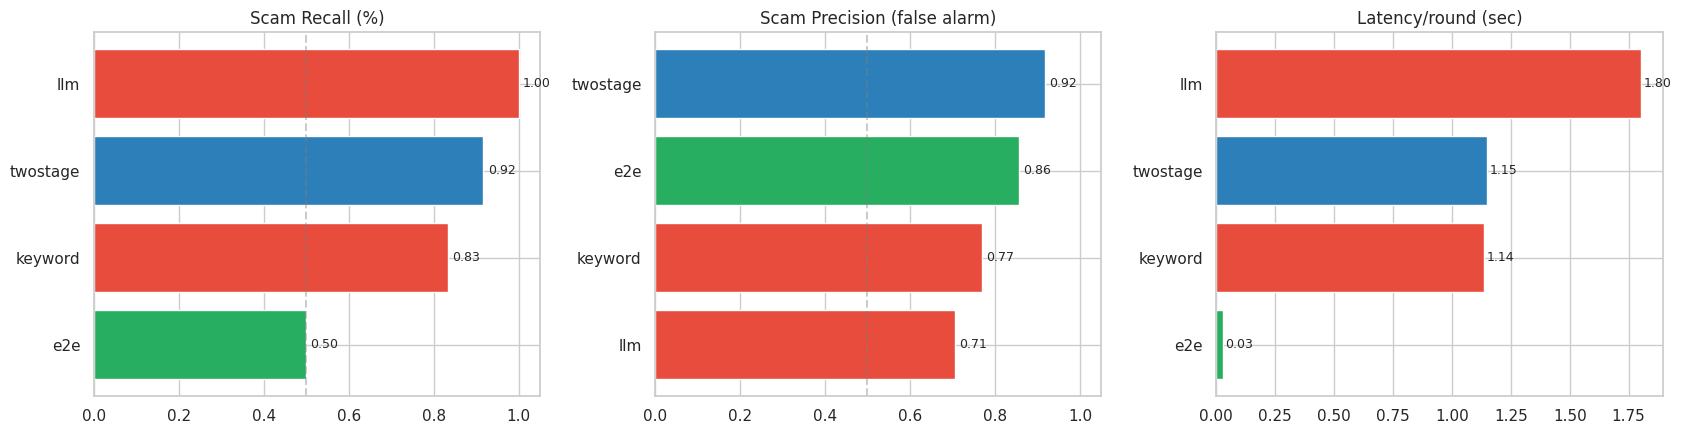


💡 ในงาน scam detection: scam_recall สำคัญสุด (พลาด scam แพงกว่า false alarm)
   GPT recall สูง = จับ scam ครบ แม้ precision ต่ำ (flag not_scam บ้าง)


In [9]:
# === Plot: scam recall + precision + latency ===
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
type_color = {'llm':'#e74c3c','keyword':'#e74c3c','twostage':'#2c7fb8','e2e':'#27ae60'}

for ax, (col, title) in zip(axes, [
        ('scam_recall','Scam Recall (%)'),
        ('scam_prec','Scam Precision (false alarm)'),
        ('lat_per_round','Latency/round (sec)')]):
    sub = summary.sort_values(col)
    ax.barh(sub.system, sub[col], color=[type_color[s] for s in sub.system])
    ax.set_title(title)
    if col != 'lat_per_round':
        ax.set_xlim(0,1.05); ax.axvline(0.5, color='gray', ls='--', alpha=0.4)
    for i,v in enumerate(sub[col]):
        ax.text(v+0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/baseline_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 ในงาน scam detection: scam_recall สำคัญสุด (พลาด scam แพงกว่า false alarm)')
print('   GPT recall สูง = จับ scam ครบ แม้ precision ต่ำ (flag not_scam บ้าง)')

In [10]:
# ดู prob ของ not_scam ที่ระบบ flag ผิด
INSPECT = 'llm'   # 🔧 เปลี่ยนเป็น 'twostage'/'e2e'/'keyword' ได้

wdf = results[INSPECT]
for fn, g in wdf.groupby('filename'):
    if g.true_label.iloc[0] == 0:   # not_scam เท่านั้น
        flagged = (g.prob_scam > SCAM_THRESHOLD).any()
        status = '🚨 WRONG (flagged scam)' if flagged else '✅ correct'
        print(f'\n📁 {fn} (TRUE: not_scam) — {status}')
        for _, r in g.sort_values('round').iterrows():
            bar = '█' * int(r.prob_scam * 20)
            mark = '🚨' if r.prob_scam > SCAM_THRESHOLD else '  '
            print(f'  {mark} [{r.start_sec:.0f}-{r.end_sec:.0f}s] {r.prob_scam:.2f} {bar}')
            if r.prob_scam > SCAM_THRESHOLD and r.transcript:
                print(f'      📝 "{r.transcript[:120]}"')


📁 rw_notscam01.mp3 (TRUE: not_scam) — 🚨 WRONG (flagged scam)
     [0-5s] 0.10 ██
     [0-10s] 0.20 ████
     [0-15s] 0.20 ████
     [5-20s] 0.20 ████
     [10-25s] 0.20 ████
  🚨 [15-30s] 0.70 ██████████████
      📝 "ครับ สี่ ห้า แปด ครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ สวัสดีครับ"
     [20-35s] 0.20 ████
     [25-40s] 0.10 ██

📁 rw_notscam02.mp3 (TRUE: not_scam) — 🚨 WRONG (flagged scam)
     [0-5s] 0.10 ██
     [0-10s] 0.10 ██
     [0-15s] 0.10 ██
     [5-20s] 0.10 ██
     [10-25s] 0.30 ██████
  🚨 [15-30s] 0.70 ██████████████
      📝 "เด้อแกลบ ไหน ๆ ศูนย์สี่เจ็ดครับ เมื่อกี้ผมแวะตอนที่ไม่รับผลาญ ผมแวะแวะไปแล้วค่ะแล้วเดี๋ยวน่าจะไปอื่นไปแล้ว ไปรับประกาศขอ"
     [20-35s] 0.20 ████
     [25-40s] 0.20 ████
  🚨 [30-45s] 0.70 ██████████████
      📝 "ครับ อันนี้ ฮัลโหล ฮัลโหล พ่อ อันนี้อันนี้อันนี้แก๊ปกดยกเลิกไปแล้วเหรอครับพอดีระบบมันจะเป็นชื่อของของของน้องอยู่แล้ว อะไ"
  🚨 [35-50s] 0.70 ██████████████
      📝 "อันนี้อันนี้อันนี้แก๊ปกดยก

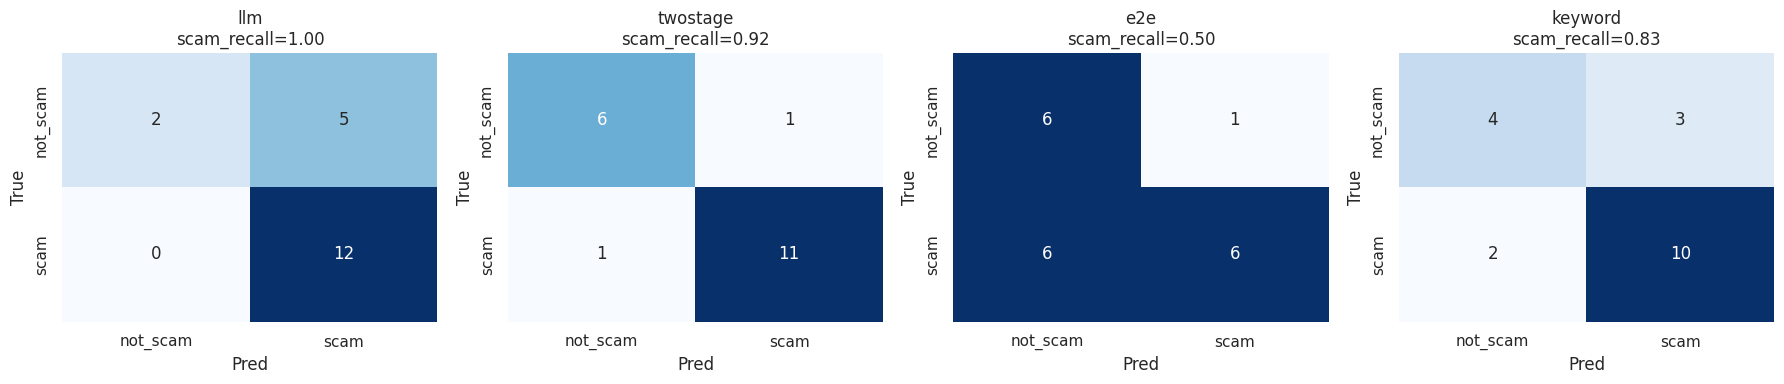

In [11]:
# Confusion matrix 4 ระบบ
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, s in zip(axes, SYSTEMS):
    wdf = results[s]
    calls = [{'true':int(g.true_label.iloc[0]),
              'pred':int((g.prob_scam>SCAM_THRESHOLD).any())} for _,g in wdf.groupby('filename')]
    cdf = pd.DataFrame(calls)
    cm = confusion_matrix(cdf.true, cdf.pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    rec = summary[summary.system==s].scam_recall.iloc[0]
    ax.set_title(f'{s}\nscam_recall={rec:.2f}'); ax.set_xlabel('Pred'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()